<a href="https://colab.research.google.com/github/nguyenvuonghongvy/Image-Captioning-Flickr8k/blob/main/BaoCao_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cài đặt thư viện

In [ ]:
!pip install kagglehub rouge-score pycocoevalcap transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 16.0 MB/s eta 0:00:0000:0100:01


#  Cấu hình (Configuration)

In [ ]:
import torch

# ==============================================================
# BẢNG ĐIỀU KHIỂN (CONTROL PANEL)
# ==============================================================

# 1. CHỌN MÔ HÌNH MUỐN CHẠY:
# Chọn 1 trong 4 tên: "ResNet-50", "EfficientNet-B3", "ViT-B/16", "CLIP-ViT-B/16"
MODEL_TO_RUN = "ViT-B/16"

# 2. SIÊU THAM SỐ (Dựa theo Phiếu báo cáo)
BATCH_SIZE = 32
LEARNING_RATE = 3e-4  # 0.0001
WEIGHT_DECAY = 1e-4   # 0.0001
GRAD_CLIP = 1.0
MAX_EPOCHS = 25       # Chạy tối đa 25 vòng, Early Stopping sẽ tự cắt sớm
EMBED_SIZE = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Đang sử dụng thiết bị: {device}")
print(f" MÔ HÌNH CHUẨN BỊ HUẤN LUYỆN: {MODEL_TO_RUN}")

 Đang sử dụng thiết bị: cuda
 MÔ HÌNH CHUẨN BỊ HUẤN LUYỆN: ViT-B/16


# Tải & Khai báo dữ liệu

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub
import torch.nn as nn
from collections import Counter
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Tải dữ liệu
path = kagglehub.dataset_download("adityajn105/flickr8k")
images_dir = os.path.join(path, "Images")
captions_file = os.path.join(path, "captions.txt")

df = pd.read_csv(captions_file)

# -------------------------------------------------------------
# 1. TẠO TỪ ĐIỂN
class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self): return len(self.itos)

    @staticmethod
    def tokenize_en(text): return text.lower().split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenize_en(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenize_en(text)
        return [self.stoi[token] if token in self.stoi else self.stoi["<UNK>"] for token in tokenized_text]

# Xây dựng từ điển chung
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(df['caption'].astype(str).tolist())

# -------------------------------------------------------------
# 2. CHIA TẬP TRAIN (80%) - VAL (10%) - TEST (10%)
unique_images = df['image'].unique()
np.random.seed(42)
np.random.shuffle(unique_images)

train_size = int(0.8 * len(unique_images))
val_size = int(0.1 * len(unique_images))

train_imgs = unique_images[:train_size]
val_imgs = unique_images[train_size:train_size+val_size]
test_imgs = unique_images[train_size+val_size:]

print(f" Chia dữ liệu: Train ({len(train_imgs)} ảnh), Val ({len(val_imgs)} ảnh), Test ({len(test_imgs)} ảnh)")

df_train = df[df['image'].isin(train_imgs)].reset_index(drop=True)
df_val = df[df['image'].isin(val_imgs)].reset_index(drop=True)
df_test = df[df['image'].isin(test_imgs)].reset_index(drop=True)

# -------------------------------------------------------------
# 3. CLASS DATASET VÀ DATALOADER
class FlickrDataset(Dataset):
    def __init__(self, df, root_dir, vocab, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.vocab = vocab
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, index):
        caption = str(self.df["caption"][index])
        img_id = self.df["image"][index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")
        if self.transform: img = self.transform(img)
        num_caption = [self.vocab.stoi["<SOS>"]] + self.vocab.numericalize(caption) + [self.vocab.stoi["<EOS>"]]
        return img, torch.tensor(num_caption)

class MyCollate:
    def __init__(self, pad_idx): self.pad_idx = pad_idx
    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)
        return imgs, targets

from PIL import Image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

pad_idx = vocab.stoi["<PAD>"]

train_loader = DataLoader(FlickrDataset(df_train, images_dir, vocab, transform), batch_size=BATCH_SIZE, shuffle=True, collate_fn=MyCollate(pad_idx))
val_loader = DataLoader(FlickrDataset(df_val, images_dir, vocab, transform), batch_size=BATCH_SIZE, shuffle=False, collate_fn=MyCollate(pad_idx))

 Chia dữ liệu: Train (6472 ảnh), Val (809 ảnh), Test (810 ảnh)


# Khởi tạo các Mô hình (Encoder Factory & Decoder)

In [ ]:
import torchvision.models as models
from transformers import CLIPVisionModel
import math

# ==============================================================
# HỆ THỐNG ENCODER LINH HOẠT (FACTORY)
# ==============================================================
class ModelFactory:
    @staticmethod
    def get_encoder(model_name, embed_size):
        if model_name == "ResNet-50":
            class ResNetEncoder(nn.Module):
                def __init__(self):
                    super().__init__()
                    self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
                    for p in self.resnet.parameters(): p.requires_grad = False
                    modules = list(self.resnet.children())[:-1]
                    self.resnet = nn.Sequential(*modules)
                    self.fc = nn.Linear(2048, embed_size)
                def forward(self, x): return self.fc(self.resnet(x).view(x.size(0), -1))
            return ResNetEncoder()

        elif model_name == "EfficientNet-B3":
            class EffNetEncoder(nn.Module):
                def __init__(self):
                    super().__init__()
                    self.eff = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
                    for p in self.eff.parameters(): p.requires_grad = False
                    self.eff.classifier[1] = nn.Linear(self.eff.classifier[1].in_features, embed_size)
                def forward(self, x): return self.eff(x)
            return EffNetEncoder()

        elif model_name == "ViT-B/16":
            class ViTEncoder(nn.Module):
                def __init__(self):
                    super().__init__()
                    self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
                    for p in self.vit.parameters(): p.requires_grad = False
                    self.vit.heads.head = nn.Linear(self.vit.heads.head.in_features, embed_size)
                def forward(self, x): return self.vit(x)
            return ViTEncoder()

        elif model_name == "CLIP-ViT-B/16":
            class CLIPEncoder(nn.Module):
                def __init__(self):
                    super().__init__()
                    self.clip = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch16")
                    for p in self.clip.parameters(): p.requires_grad = False
                    self.fc = nn.Linear(self.clip.config.hidden_size, embed_size)
                def forward(self, x): return self.fc(self.clip(pixel_values=x).pooler_output)
            return CLIPEncoder()

        else:
            raise ValueError(f"Mô hình {model_name} không hợp lệ!")

# Khởi tạo Encoder theo cấu hình
encoder = ModelFactory.get_encoder(MODEL_TO_RUN, EMBED_SIZE).to(device)

# ==============================================================
# TRANSFORMER DECODER
# ==============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=100):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
    def forward(self, x): return self.dropout(x + self.pe[:x.size(0)])

class TransformerDecoderModel(nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads=8, num_layers=3, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoder = PositionalEncoding(embed_size, dropout)
        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_size, nhead=num_heads, dropout=dropout)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_size, vocab_size)
        self.embed_size = embed_size

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, features, captions):
        captions = captions.transpose(0, 1)
        seq_len = captions.shape[0]
        embeddings = self.pos_encoder(self.embedding(captions) * math.sqrt(self.embed_size))
        features = features.unsqueeze(0)
        tgt_mask = self.generate_square_subsequent_mask(seq_len).to(captions.device)
        output = self.transformer_decoder(tgt=embeddings, memory=features, tgt_mask=tgt_mask)
        return self.fc_out(output).transpose(0, 1)

# Khởi tạo Decoder
decoder = TransformerDecoderModel(len(vocab), EMBED_SIZE).to(device)
print(f" Đã tải xong Pipeline cho: {MODEL_TO_RUN}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 164MB/s]  


 Đã tải xong Pipeline cho: ViT-B/16


# Thuật toán Early Stopping & Vòng lặp Huấn luyện

In [ ]:
import time
import numpy as np
import torch.optim as optim

class EarlyStopping:
    def __init__(self, patience=3, verbose=True, model_name="model"):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.model_name = model_name
        self.best_epoch = 0

    def __call__(self, val_loss, encoder, decoder, epoch):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, encoder, decoder)
            self.best_epoch = epoch
        elif score < self.best_score:
            self.counter += 1
            if self.verbose: print(f'Cảnh báo: Không cải thiện {self.counter}/{self.patience}')
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, encoder, decoder)
            self.counter = 0
            self.best_epoch = epoch

    def save_checkpoint(self, val_loss, encoder, decoder):
        # Chuyển dấu / thành dấu - để không bị lỗi thư mục ảo
        safe_name = self.model_name.replace("/", "-")
        if self.verbose: print(f'Validation loss giảm ({self.val_loss_min:.6f} --> {val_loss:.6f}). Đang lưu mô hình...')
        torch.save(encoder.state_dict(), f'encoder_{safe_name}.pth')
        torch.save(decoder.state_dict(), f'decoder_{safe_name}.pth')
        self.val_loss_min = val_loss

# ==============================================================
# BẮT ĐẦU HUẤN LUYỆN
# ==============================================================
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
params = list(decoder.parameters()) + list(filter(lambda p: p.requires_grad, encoder.parameters()))
optimizer = optim.Adam(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
early_stopping = EarlyStopping(patience=3, model_name=MODEL_TO_RUN)

print(f"\n🚀 BẮT ĐẦU HUẤN LUYỆN: {MODEL_TO_RUN}")
t0_pipeline = time.time()
total_feature_time = 0
total_decoder_time = 0

for epoch in range(MAX_EPOCHS):
    encoder.train()
    decoder.train()
    train_loss = 0

    # 1. PHA HUẤN LUYỆN (TRAINING)
    t0_train = time.time()
    for batch_idx, (imgs, captions) in enumerate(train_loader):
        imgs, captions = imgs.to(device), captions.to(device)

        # Đo thời gian trích xuất đặc trưng
        t_feat_start = time.time()
        features = encoder(imgs)
        total_feature_time += (time.time() - t_feat_start)

        # Đo thời gian train decoder
        t_dec_start = time.time()
        outputs = decoder(features, captions[:, :-1])
        targets = captions[:, 1:]
        loss = criterion(outputs.reshape(-1, outputs.shape[2]), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=GRAD_CLIP)
        optimizer.step()
        total_decoder_time += (time.time() - t_dec_start)
        train_loss += loss.item()

        # IN TIẾN ĐỘ TỪNG BATCH ĐỂ THEO DÕI
        if batch_idx % 100 == 0:
            print(f"   Đang xử lý Batch [{batch_idx}/{len(train_loader)}]...")

    avg_train_loss = train_loss / len(train_loader)
    train_duration = time.time() - t0_train

    # 2. PHA ĐÁNH GIÁ (VALIDATION)
    encoder.eval()
    decoder.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, captions in val_loader:
            imgs, captions = imgs.to(device), captions.to(device)
            features = encoder(imgs)
            outputs = decoder(features, captions[:, :-1])
            loss = criterion(outputs.reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    print(f"\nEpoch [{epoch+1}/{MAX_EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | T/gian vòng lặp: {train_duration:.1f}s")

    # 3. EARLY STOPPING
    early_stopping(avg_val_loss, encoder, decoder, epoch+1)
    if early_stopping.early_stop:
        print(" Đã kích hoạt dừng sớm (Early Stopping) để chống học vẹt!")
        break

total_pipeline_time = time.time() - t0_pipeline

# Nạp lại trọng số tốt nhất để chuẩn bị kiểm thử
safe_name = MODEL_TO_RUN.replace("/", "-")
encoder.load_state_dict(torch.load(f'encoder_{safe_name}.pth'))
decoder.load_state_dict(torch.load(f'decoder_{safe_name}.pth'))

print("\n" + "="*50)
print(" BẢNG BÁO CÁO THỜI GIAN VÀ LOSS (Điền vào Word)")
print("="*50)
print(f"Mô hình: {MODEL_TO_RUN}")
print(f"Epoch tốt nhất (Dừng sớm): {early_stopping.best_epoch}")
print(f"Validation loss tại epoch tốt nhất: {early_stopping.val_loss_min:.6f}")
print(f"Thời gian huấn luyện (Tổng vòng lặp): {total_pipeline_time:.2f} s")
print(f"Trích feature (Tổng): {total_feature_time:.2f} s")
print(f"Train decoder (Tổng): {total_decoder_time:.2f} s")
print(f"Tổng pipeline: {total_pipeline_time:.2f} s")


🚀 BẮT ĐẦU HUẤN LUYỆN: ViT-B/16
   Đang xử lý Batch [0/1012]...
   Đang xử lý Batch [100/1012]...
   Đang xử lý Batch [200/1012]...
   Đang xử lý Batch [300/1012]...
   Đang xử lý Batch [400/1012]...
   Đang xử lý Batch [500/1012]...
   Đang xử lý Batch [600/1012]...
   Đang xử lý Batch [700/1012]...
   Đang xử lý Batch [800/1012]...
   Đang xử lý Batch [900/1012]...
   Đang xử lý Batch [1000/1012]...

Epoch [1/25] | Train Loss: 3.4326 | Val Loss: 2.9261 | T/gian vòng lặp: 781.8s
Validation loss giảm (inf --> 2.926085). Đang lưu mô hình...
   Đang xử lý Batch [0/1012]...
   Đang xử lý Batch [100/1012]...
   Đang xử lý Batch [200/1012]...
   Đang xử lý Batch [300/1012]...
   Đang xử lý Batch [400/1012]...
   Đang xử lý Batch [500/1012]...
   Đang xử lý Batch [600/1012]...
   Đang xử lý Batch [700/1012]...
   Đang xử lý Batch [800/1012]...
   Đang xử lý Batch [900/1012]...
   Đang xử lý Batch [1000/1012]...

Epoch [2/25] | Train Loss: 2.7587 | Val Loss: 2.7274 | T/gian vòng lặp: 666.4s
V

# Kiểm thử trên tập TEST (Tính 5 chỉ số tự động)

In [ ]:
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

def generate_caption(img_path, encoder, decoder, vocab, max_len=20):
    encoder.eval()
    decoder.eval()
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        features = encoder(img)
        predicted_caption = [vocab.stoi["<SOS>"]]
        for _ in range(max_len):
            cap_tensor = torch.tensor(predicted_caption).unsqueeze(0).to(device)
            outputs = decoder(features, cap_tensor)
            pred_idx = outputs[:, -1, :].argmax(1).item()
            predicted_caption.append(pred_idx)
            if pred_idx == vocab.stoi["<EOS>"]: break

    return [vocab.itos[idx] for idx in predicted_caption if idx not in [vocab.stoi["<SOS>"], vocab.stoi["<EOS>"], vocab.stoi["<PAD>"]]]

print("\nĐang sinh câu trên tập Test và chấm điểm tự động...")

gts = {}
res = {}
actual_captions_list = []
predicted_captions_list = []
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
total_meteor, total_rouge_l = 0, 0

# Lấy 100 ảnh Test để chạy cho nhanh (hoặc test_imgs nếu muốn chạy hết)
test_sample = test_imgs[:100]

for i, img_name in enumerate(test_sample):
    img_captions = df_test[df_test['image'] == img_name]['caption'].tolist()

    # For BLEU & METEOR
    refs_words = [vocab.tokenize_en(str(cap)) for cap in img_captions]
    actual_captions_list.append(refs_words)

    # Generate
    img_path = os.path.join(images_dir, img_name)
    pred_words = generate_caption(img_path, encoder, decoder, vocab)
    predicted_captions_list.append(pred_words)

    # For CIDEr & ROUGE
    gts[i] = [str(cap) for cap in img_captions]
    pred_sentence = " ".join(pred_words)
    res[i] = [pred_sentence]

    # ROUGE & METEOR
    total_meteor += meteor_score(refs_words, pred_words)
    best_rouge = max([scorer.score(" ".join(ref), pred_sentence)['rougeL'].fmeasure for ref in refs_words])
    total_rouge_l += best_rouge

# Tính toán
bleu_1 = corpus_bleu(actual_captions_list, predicted_captions_list, weights=(1.0, 0, 0, 0))
bleu_4 = corpus_bleu(actual_captions_list, predicted_captions_list, weights=(0.25, 0.25, 0.25, 0.25))
avg_meteor = total_meteor / len(test_sample)
avg_rouge = total_rouge_l / len(test_sample)
cider_score, _ = Cider().compute_score(gts, res)

print("\n" + "="*50)
print(" BẢNG BÁO CÁO 5 CHỈ SỐ (Điền vào Word)")
print("="*50)
print(f"Mô hình: {MODEL_TO_RUN}")
print(f"BLEU-1:  {bleu_1:.6f}")
print(f"BLEU-4:  {bleu_4:.6f}")
print(f"METEOR:  {avg_meteor:.6f}")
print(f"ROUGE-L: {avg_rouge:.6f}")
print(f"CIDEr:   {cider_score:.6f}")


Đang sinh câu trên tập Test và chấm điểm tự động...

 BẢNG BÁO CÁO 5 CHỈ SỐ (Điền vào Word)
Mô hình: ViT-B/16
BLEU-1:  0.617450
BLEU-4:  0.197329
METEOR:  0.410657
ROUGE-L: 0.438607
CIDEr:   0.484708


# Một số caption minh họa

--- ẢNH MINH HỌA TỪ MÔ HÌNH: ViT-B/16 ---


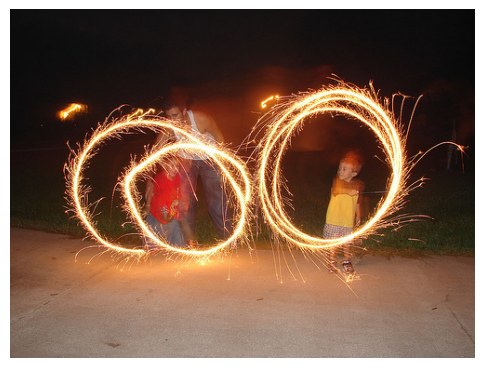

 CÁC CAPTION GỐC CỦA NGƯỜI (Ground Truth):
  1. Children play with large hoops .
  2. Little kids playing with sparklers at night .
  3. Two small children are twirling sparkling rope .
  4. Two young boys playing with sparklers .
  5. Two young children and an older man play with sparklers .

 MÔ HÌNH AI DỰ ĐOÁN:
  -> a young man is standing on a tire with a <UNK> .




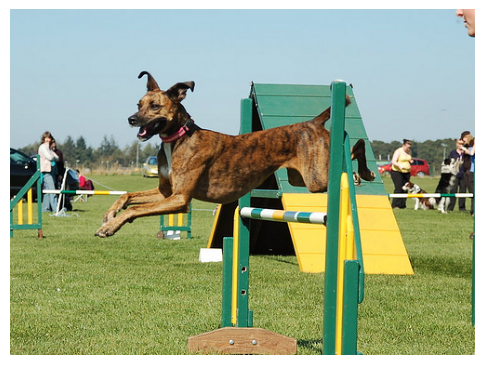

 CÁC CAPTION GỐC CỦA NGƯỜI (Ground Truth):
  1. A brown dog jumping over an obstacle hurdle .
  2. A dog jumps over a hurdle .
  3. A large tri-colored dog clears a green , yellow and white jump set up in the grass .
  4. Brown dog jumping over a bar on a grassy field .
  5. Brown dog jumping over a hurdle .

 MÔ HÌNH AI DỰ ĐOÁN:
  -> a dog jumping over a hurdle .




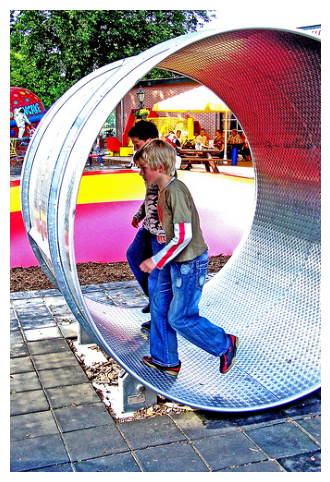

 CÁC CAPTION GỐC CỦA NGƯỜI (Ground Truth):
  1. Two boys are running in a metal barrel .
  2. Two boys are running in a spinning tube .
  3. Two boys are walking inside a human-size exercise-wheel .
  4. Two boys running in a giant metal wheel .
  5. Two boys walking to make a cylinder roll at a small carnival .

 MÔ HÌNH AI DỰ ĐOÁN:
  -> a little girl is sliding down a <UNK> slide .




In [ ]:
import matplotlib.pyplot as plt
import random

def show_image_with_caption(img_name):
    img_path = os.path.join(images_dir, img_name)

    # Lấy các câu miêu tả gốc của con người
    real_captions = df_test[df_test['image'] == img_name]['caption'].tolist()

    # Bắt AI tự miêu tả
    pred_words = generate_caption(img_path, encoder, decoder, vocab)
    predicted_caption = " ".join(pred_words)

    # Hiển thị ảnh
    img = Image.open(img_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print(" CÁC CAPTION GỐC CỦA NGƯỜI (Ground Truth):")
    for i, cap in enumerate(real_captions):
        print(f"  {i+1}. {cap}")
    print("\n MÔ HÌNH AI DỰ ĐOÁN:")
    print(f"  -> {predicted_caption}")
    print("\n")

# Bốc ngẫu nhiên 3 bức ảnh trong tập Test để xem thử
print(f"--- ẢNH MINH HỌA TỪ MÔ HÌNH: {MODEL_TO_RUN} ---")
sample_images = random.sample(list(test_imgs), 3)
for img_name in sample_images:
    print("="*60)
    show_image_with_caption(img_name)